# 3.4 导读与数学基础：多目标学习

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入 MMoE 与 PLE 前，理解多任务损失、共享与专属参数、Softmax gate、梯度冲突和负迁移。

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [MMoE](https://dl.acm.org/doi/10.1145/3219819.3220007) · [PLE](https://dl.acm.org/doi/10.1145/3383313.3412236)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 共享方式 | 任务专属结构 | 主要风险 |
|---|---|---|---|
| 3.4.1 MMoE | 所有任务共享专家 | 每任务 gate 与 tower | 专家塌缩、梯度冲突 |
| 3.4.2 PLE | 逐层共享专家 | 每层保留任务专属专家 | 参数与调参成本 |
| 3.4 总结 | 相同真实评分子集比较 | 逐任务指标 | 平均值掩盖跷跷板 |

MMoE 适合相关任务的灵活共享；PLE 适合确有负迁移且数据足够支撑更复杂结构的场景。上线仍需明确最终业务效用函数。

## 来源论文解读

- **MMoE (2018)** 用任务独立 gate 混合同一组专家，在任务相关性变化时比 hard sharing 更灵活。
- **PLE (2020)** 在每层区分共享和任务专属专家，逐步提取可共享信息，针对负迁移和跷跷板问题。

二者都不能自动解决标签空间不一致。例如 CVR 只在点击样本上观测，必须配合样本掩码、ESMM 类概率分解或因果校正。

## 共同数学：加权损失、Gate 与梯度夹角

多任务总损失常写成 $L=\sum_t\lambda_tL_t$。权重 $\lambda_t$ 不只是数学常数，它决定优化器更重视哪个任务。

MMoE 的任务表示为 $z_t=\sum_e g_{t,e}(x)f_e(x)$，Softmax gate 满足 $\sum_e g_{t,e}=1$。

两个任务梯度的余弦 $\cos(g_1,g_2)=g_1^\top g_2/(\|g_1\|\|g_2\|)$：大于 0 表示大致同向，小于 0 表示一步更新可能帮助一个任务却伤害另一个任务。

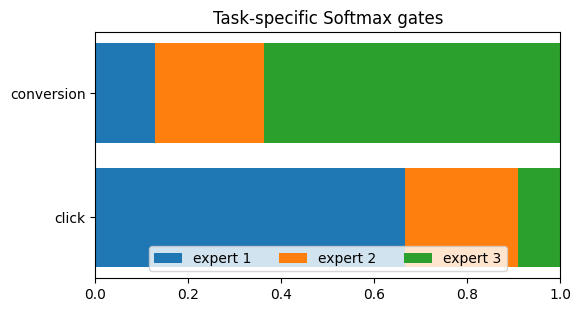

{'gate_sums': [1.0, 1.0], 'gradient_cosine': -0.263}


In [2]:
import numpy as np, matplotlib.pyplot as plt
gate_logits=np.array([[2.,1.,0.],[.2,.8,1.8]])
gate=np.exp(gate_logits); gate/=gate.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(6,3.2)); left=np.zeros(2)
for expert in range(3):
    ax.barh(['click','conversion'],gate[:,expert],left=left,label=f'expert {expert+1}'); left+=gate[:,expert]
ax.set(xlim=(0,1),title='Task-specific Softmax gates'); ax.legend(ncol=3,loc='lower center'); plt.show()
grad_click=np.array([1.,.2]); grad_convert=np.array([-.5,1.])
cosine=grad_click@grad_convert/(np.linalg.norm(grad_click)*np.linalg.norm(grad_convert))
print({'gate_sums':gate.sum(1).round(3).tolist(),'gradient_cosine':round(float(cosine),3)})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
assert np.allclose(gate.sum(1),1)
assert -1<=cosine<=1
print('PASS：任务 gate 是合法权重，梯度夹角位于合法范围。')

PASS：任务 gate 是合法权重，梯度夹角位于合法范围。


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。